In [10]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, Dropout, MaxPooling2D, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import cifar100 
import matplotlib.pyplot as plt #imports

In [2]:
(X_train, y_train), (X_test, y_test) = cifar100.load_data() #carrega os dados

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 2131s 13us/step


/home/voraztitan/miniconda3/envs/numpylib/lib/python3.12/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


In [3]:
X_train, X_test = X_train / 255.0, X_test / 255.0 #normalizando entre 0 e 1

In [17]:
i = Input(shape = X_train[0].shape) #camada de entrada

rede = Conv2D(64, (3, 3), activation = 'relu', padding = 'same')(i) #camada de convolucao
rede = BatchNormalization()(rede) #normalização pra proxima camada
rede = MaxPooling2D((2, 2))(rede) #pooling pra diminuir 
rede = Dropout(0.2)(rede) #desativando neuronio

rede = Conv2D(128, (3, 3), activation = 'relu', padding = 'same')(i) #camada de convolucao com mais filtros
rede = BatchNormalization()(rede) #normalização pra proxima camada
rede = MaxPooling2D((2, 2))(rede) #pooling pra diminuir e pegar caracteristicas
rede = Dropout(0.3)(rede) #desativando 30% dos neuronios

rede = Flatten()(rede) #passa pra vetor
rede = Dense(512, activation = 'relu')(rede)
rede = Dropout(0.4)(rede) #40% de neuronios desativados
rede = Dense(100, activation = 'softmax')(rede) #100 pq tem 100 categorias

modelo = Model(i, rede) #define o modelo

modelo.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy']) #compila a rede

In [19]:
modelo.summary() #sumario da rede

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 128)    │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │    16,777,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 100)            │        51,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,833,124 (64.21 MB)

 Trainable params: 16,832,868 (64.21 MB)

 Non-trainable params: 256 (1.00 KB)

In [9]:
respostas = modelo.fit(X_train, y_train, validation_data = (X_test, y_test), epochs = 20) #treinando

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 120s 76ms/step - accuracy: 0.1286 - loss: 3.8785 - val_accuracy: 0.2243 - val_loss: 3.2881
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 148s 95ms/step - accuracy: 0.2142 - loss: 3.2844 - val_accuracy: 0.2346 - val_loss: 3.2177
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 150s 96ms/step - accuracy: 0.2701 - loss: 2.9777 - val_accuracy: 0.2721 - val_loss: 3.0082
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 154s 98ms/step - accuracy: 0.3215 - loss: 2.7214 - val_accuracy: 0.2723 - val_loss: 3.1072
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 154s 98ms/step - accuracy: 0.3663 - loss: 2.4995 - val_accuracy: 0.3179 - val_loss: 2.8231
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 165s 106ms/step - accuracy: 0.4134 - loss: 2.2994 - val_accuracy: 0.2988 - val_loss: 3.0401
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 172s 110ms/step - accuracy: 0.4442 - loss: 2.1386 - val_accuracy: 0.3264 - val_loss: 2.8677
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 170s 109ms/step - accurac

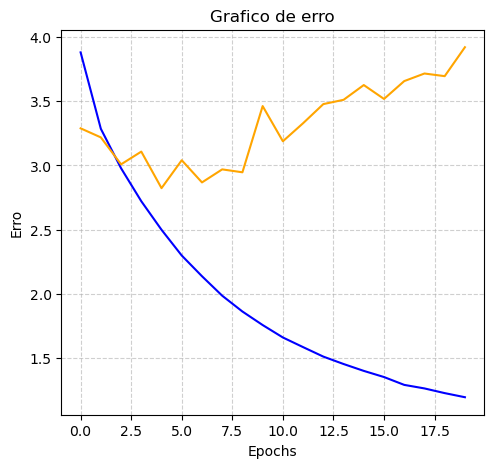

In [12]:
plt.figure(figsize = (12, 5)) #definindo o tamanho

plt.subplot(1, 2, 1) #1 linha 2 colunas 
plt.plot(respostas.history['loss'], label = 'Loss', color = 'blue') #define o erro no grafico
plt.plot(respostas.history['val_loss'], label = 'Val Loss', color = 'orange') #define o erro de validacao
plt.title('Grafico de erro') #titulo
plt.xlabel('Epochs') #titulo do eixo x
plt.ylabel('Erro') #titulo do eixo y
plt.grid(True, linestyle = '--', alpha = 0.6) #definindo as linha dentro do quadrado

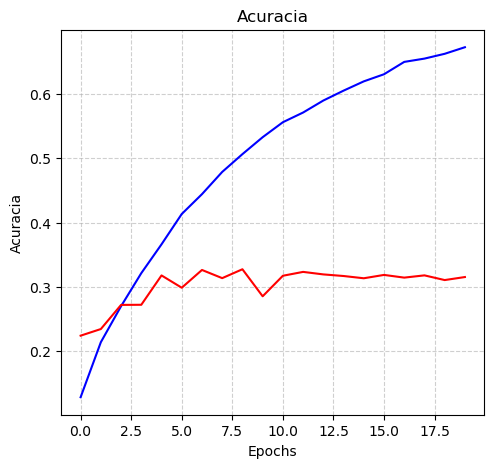

In [15]:
plt.figure(figsize = (12, 5)) #definindo o tamanho

plt.subplot(1, 2, 2) #1 linha 2 colunas
plt.plot(respostas.history['accuracy'], label = 'Acuracia', color = 'blue') #define a acuracia no grafico
plt.plot(respostas.history['val_accuracy'], label = 'Val Accuracy', color = 'red') #define a validacao da acurafia
plt.title('Acuracia') #titulo
plt.xlabel('Epochs') #titulo da label x
plt.ylabel('Acuracia') #titula da label y
plt.grid(True, linestyle = '--', alpha = 0.6)

In [20]:
respostas = modelo.fit(X_train, y_train, validation_data = (X_test, y_test), epochs = 10) #treinando com menos epoca pra comparar o vall loss e a vall accuracy

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 124s 79ms/step - accuracy: 0.1287 - loss: 3.8662 - val_accuracy: 0.2108 - val_loss: 3.2864
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 150s 96ms/step - accuracy: 0.2233 - loss: 3.2359 - val_accuracy: 0.2649 - val_loss: 3.0194
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 163s 104ms/step - accuracy: 0.2795 - loss: 2.9309 - val_accuracy: 0.2879 - val_loss: 2.8875
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 157s 100ms/step - accuracy: 0.3215 - loss: 2.7091 - val_accuracy: 0.3089 - val_loss: 2.7930
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 157s 100ms/step - accuracy: 0.3613 - loss: 2.5091 - val_accuracy: 0.3096 - val_loss: 2.8659
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 164s 105ms/step - accuracy: 0.3988 - loss: 2.3289 - val_accuracy: 0.3196 - val_loss: 2.7780
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 155s 99ms/step - accuracy: 0.4351 - loss: 2.1688 - val_accuracy: 0.3271 - val_loss: 2.8381
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 155s 99ms/step - accura

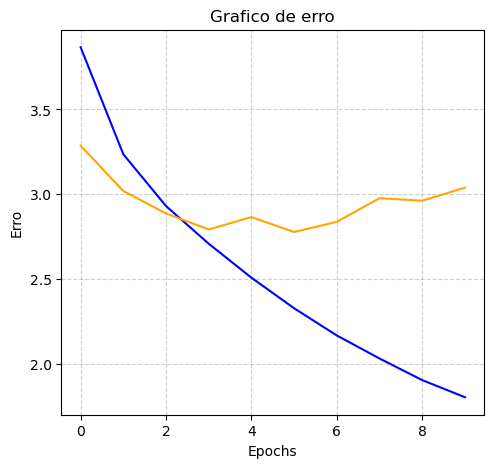

In [21]:
plt.figure(figsize = (12, 5)) #definindo o tamanho

plt.subplot(1, 2, 1) #1 linha 2 colunas 
plt.plot(respostas.history['loss'], label = 'Loss', color = 'blue') #define o erro no grafico
plt.plot(respostas.history['val_loss'], label = 'Val Loss', color = 'orange') #define o erro de validacao
plt.title('Grafico de erro') #titulo
plt.xlabel('Epochs') #titulo do eixo x
plt.ylabel('Erro') #titulo do eixo y
plt.grid(True, linestyle = '--', alpha = 0.6) #definindo as linha dentro do quadrado

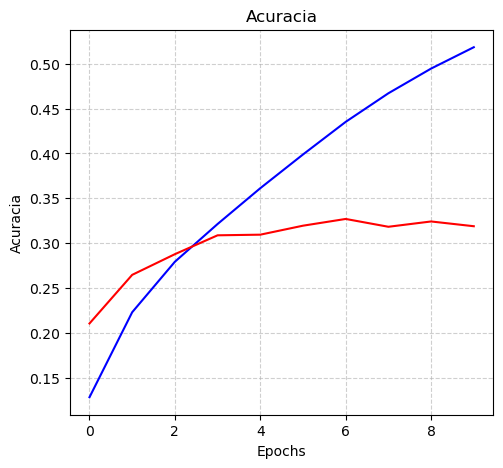

In [22]:
plt.figure(figsize = (12, 5)) #definindo o tamanho

plt.subplot(1, 2, 2) #1 linha 2 colunas
plt.plot(respostas.history['accuracy'], label = 'Acuracia', color = 'blue') #define a acuracia no grafico
plt.plot(respostas.history['val_accuracy'], label = 'Val Accuracy', color = 'red') #define a validacao da acurafia
plt.title('Acuracia') #titulo
plt.xlabel('Epochs') #titulo da label x
plt.ylabel('Acuracia') #titula da label y
plt.grid(True, linestyle = '--', alpha = 0.6)